In [1]:
# TASK 2: SENTIMENT ANALYSIS
# Deliverable: A Jupyter notebook showcasing preprocessing, modeling, and evaluation.

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# 1. Create a Synthetic Dataset (Fastest way)
# We create a small dataset of reviews to avoid downloading external files.
data = {
    'review': [
        "I love this product, it is amazing!",
        "Terrible service, very disappointed.",
        "Great quality and fast delivery.",
        "Not worth the money, bad experience.",
        "Absolutely fantastic! Highly recommend.",
        "The item was broken when it arrived.",
        "Good value for the price.",
        "Worst purchase I have ever made.",
        "I am very happy with my order.",
        "Do not buy this, it is a scam."
    ],
    'sentiment': [
        "Positive", "Negative", "Positive", "Negative", "Positive",
        "Negative", "Positive", "Negative", "Positive", "Negative"
    ]
}
df = pd.DataFrame(data)
print("Dataset Sample:\n", df.head())

Dataset Sample:
                                     review sentiment
0      I love this product, it is amazing!  Positive
1     Terrible service, very disappointed.  Negative
2         Great quality and fast delivery.  Positive
3     Not worth the money, bad experience.  Negative
4  Absolutely fantastic! Highly recommend.  Positive


In [9]:
# 2. Preprocessing & TF-IDF Vectorization
# Convert text data into numerical vectors
tfidf = TfidfVectorizer(stop_words='english')
X = tfidf.fit_transform(df['review'])
y = df['sentiment']

In [5]:
# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
# 4. Train Model (Logistic Regression)
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [10]:
# 5. Evaluation
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {acc * 100:.2f}%")

# Test with a new custom sentence
new_review = ["This product is really great and useful"]
new_vec = tfidf.transform(new_review)
prediction = model.predict(new_vec)
print(f"\nTest Review: '{new_review[0]}'")
print(f"Predicted Sentiment: {prediction[0]}")


Model Accuracy: 33.33%

Test Review: 'This product is really great and useful'
Predicted Sentiment: Positive


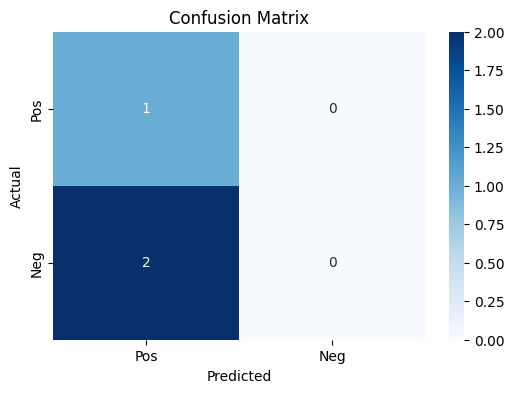

In [11]:
# 6. Visualization (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred, labels=["Positive", "Negative"])
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pos", "Neg"], yticklabels=["Pos", "Neg"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# NOTE FOR SUBMISSION:
# Used TF-IDF to vectorize text reviews and Logistic Regression for classification.